Matplotlib is building the font cache; this may take a moment.


Dataset Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  Skinthickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
[0]	validation_0-logloss:0.60872	validation_1-logloss:0.62229
[1]	validation_0-logloss:0.57802	validation_1-logloss:0.59927
[2]	validation_0-logloss:0.55252	validation_1-logloss:0.57946
[3]	validation_0-logloss:0.52971	validation_1-logloss:0.56331
[4]	validation_0-logloss:0.5101

C:\Users\kamalesh\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:29:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model Accuracy: 0.7792207792207793


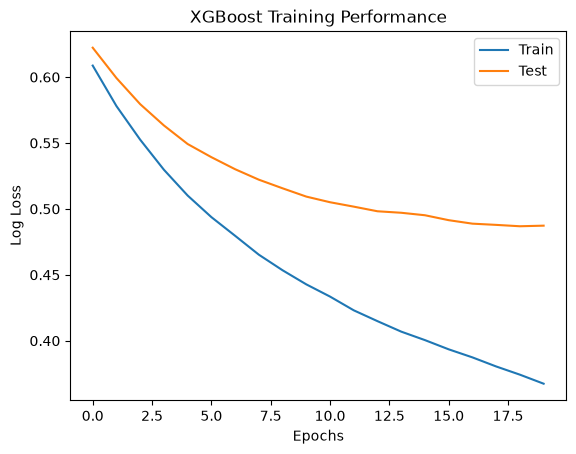


Model saved successfully as:
1. diabetes_xgboost_model.model
2. diabetes_xgboost_model.pkl


C:\Users\kamalesh\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\sklearn.py:1122: UserWarning: [12:29:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1564: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import joblib

# ==========================================
# LOAD DATASET
# ==========================================
data = pd.read_csv(r"E:\MUKESH\DIABETES_PREDICTION\diabetes.csv")

print("Dataset Shape:", data.shape)
print(data.head())

# ==========================================
# HANDLE MISSING VALUES (if any)
# ==========================================
data = data.fillna(data.mean(numeric_only=True))

# ==========================================
# ENCODE CATEGORICAL DATA
# ==========================================
label_encoders = {}

for column in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# ==========================================
# DEFINE FEATURES AND TARGET
# (Change 'Outcome' to your target column name)
# ==========================================
target_column = "Outcome"   # ⚠ Change if needed

X = data.drop(columns=[target_column])
y = data[target_column]

# ==========================================
# TRAIN TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# XGBOOST MODEL WITH 20 EPOCHS
# ==========================================
model = xgb.XGBClassifier(
    n_estimators=20,       # 20 epochs
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

eval_set = [(X_train, y_train), (X_test, y_test)]

model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=True
)

# ==========================================
# PREDICTION
# ==========================================
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

# ==========================================
# PLOT TRAINING GRAPH
# ==========================================
results = model.evals_result()

epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure()
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Test')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("XGBoost Training Performance")
plt.show()

# ==========================================
# SAVE MODEL AS UNOPENABLE BINARY FILE
# ==========================================
model.save_model("diabetes_xgboost_model.model")

# Also save using joblib (binary format)
joblib.dump(model, "diabetes_xgboost_model.pkl")

print("\nModel saved successfully as:")
print("1. diabetes_xgboost_model.model")
print("2. diabetes_xgboost_model.pkl")